In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

# 1. Linear Regression



### - Simple Linear regression

In [4]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train) #fit command is used to train the model on the training data. It takes the input features (X_train) and the target variable (y_train) and learns the relationship between them. After fitting the model, it can be used to make predictions on new data.

lr.predict(X_test) #predict command is used to make predictions on the test data. It takes the input features (X_test) and uses the trained model to predict the target variable (y_test). The output will be the predicted values for the test data based on the learned relationship from the training data.

NameError: name 'X_train' is not defined

In [ ]:
y_test.values

In [ ]:
lr.coef_ #coef_ command is used to access the coefficients of the linear regression model. It returns an array of coefficients corresponding to each input feature. These coefficients represent the strength and direction of the relationship between each feature and the target variable. A positive coefficient indicates a positive relationship, while a negative coefficient indicates a negative relationship. The magnitude of the coefficient indicates the strength of the relationship, with larger absolute values indicating stronger relationships. 

lr.intercept_ #intercept_ command is used to access the intercept of the linear regression model. The intercept represents the expected value of the target variable when all input features are equal to zero. It is the point where the regression line crosses the y-axis. The intercept can provide insights into the baseline level of the target variable when there are no input features influencing it.

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


mae= mean_absolute_error(y_test,y_pred) #mean_absolute_error command is used to calculate the mean absolute error between the true values (y_test) and the predicted values (lr.predict(X_test)). The mean absolute error is a measure of the average magnitude of the errors in a set of predictions, without considering their direction. It is calculated as the average of the absolute differences between the true values and the predicted values. A lower mean absolute error indicates better model performance, as it means that the predictions are closer to the true values on average.

mse= mean_squared_error(y_test,y_pred)

rmse = mean_squared_error(y_test,y_pred,squared=False) #mean_squared_error command is used to calculate the mean squared error between the true values (y_test) and the predicted values (lr.predict(X_test)). The mean squared error is a measure of the average squared difference between the true values and the predicted values. It is calculated as the average of the squared differences between the true values and the predicted values. A lower mean squared error indicates better model performance, as it means that the predictions are closer to the true values on average. The parameter squared=False is used to return the root mean squared error (RMSE) instead of the mean squared error (MSE). RMSE is a commonly used metric for evaluating regression models, as it provides a more interpretable measure of the average prediction error in the same units as the target variable.

r2 = r2_score(y_test,y_pred) #r2_score command is used to calculate the R-squared (R²) score between the true values (y_test) and the predicted values (lr.predict(X_test)). The R-squared score is a statistical measure that represents the proportion of the variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1, where a higher R-squared score indicates a better fit of the model to the data. An R-squared score of 1 indicates that the model perfectly explains the variance in the target variable, while an R-squared score of 0 indicates that the model does not explain any of the variance in the target variable.

#adjusted R-squared is a modified version of R-squared that takes into account the number of predictors in the model. It is calculated as:
n = len(y_test) #number of rows in the test set
k = X_test.shape[1] #number of independednt columns
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1)) #adjusted R-squared is calculated using the formula: Adjusted R² = 1 - (1 - R²) * (n - 1) / (n - p - 1), where n is the number of observations and p is the number of predictors. The adjusted R-squared provides a more accurate measure of model performance by penalizing the addition of unnecessary predictors, which can lead to overfitting. A higher adjusted R-squared indicates a better fit of the model to the data, while a lower adjusted R-squared indicates a poorer fit.

How much shouold these scores be?

### - Polynomial regression


In [ ]:
from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2,include_bias=True) #degree 

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_trans,y_train)

y_pred = lr.predict(X_test_trans)

# ye wala dekh lena
# SGDRegressor is a linear model that estimates the coefficients of a linear regression model using stochastic gradient descent (SGD) optimization. It is an efficient algorithm for training linear models on large datasets, as it updates the model parameters incrementally for each training example, rather than computing the gradients for the entire dataset at once. SGDRegressor can be used for both regression and classification tasks, and it supports various loss functions and regularization techniques to prevent overfitting. It is particularly useful when dealing with high-dimensional data or when the dataset is too large to fit into memory.

In [ ]:
from sklearn.linear_model import Ridge

R=Ridge(alpha=100000)

#use cross validation to find the best alpha value for Ridge regression

from sklearn.model_selection import GridSearchCV

parameters = {'alpha':[0.1,1,10,100,1000,10000,100000,1000000]}
grid = GridSearchCV(R,parameters,cv=5)
grid.fit(X_train,y_train)
grid.best_params_

R=Ridge(alpha=best one found)

R.fit(X_train,y_train)

y_pred = R.predict(X_test)


In [ ]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet

reg = ElasticNet(alpha=0.005,l1_ratio=0.9) #alpha is the regularization parameter that controls the strength of the regularization. A higher alpha value will result in stronger regularization, while a lower alpha value will result in weaker regularization. The l1_ratio parameter controls the balance between L1 and L2 regularization. A l1_ratio of 0 corresponds to L2 regularization (Ridge), while a l1_ratio of 1 corresponds to L1 regularization (Lasso). A l1_ratio between 0 and 1 allows for a combination of both L1 and L2 regularization.
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)

# or 

sgd=SGDRegressor(alpha=0.005,penalty='elasticnet',l1_ratio=0.9) #alpha is the regularization parameter that controls the strength of the regularization. A higher alpha value will result in stronger regularization, while a lower alpha value will result in weaker regularization. The penalty parameter specifies the type of regularization to apply, with 'elasticnet' indicating a combination of L1 and L2 regularization. The l1_ratio parameter controls the balance between L1 and L2 regularization, with a l1_ratio of 0 corresponding to L2 regularization (Ridge), a l1_ratio of 1 corresponding to L1 regularization (Lasso), and a l1_ratio between 0 and 1 allowing for a combination of both L1 and L2 regularization.
sgd.fit(X_train,y_train)
y_pred

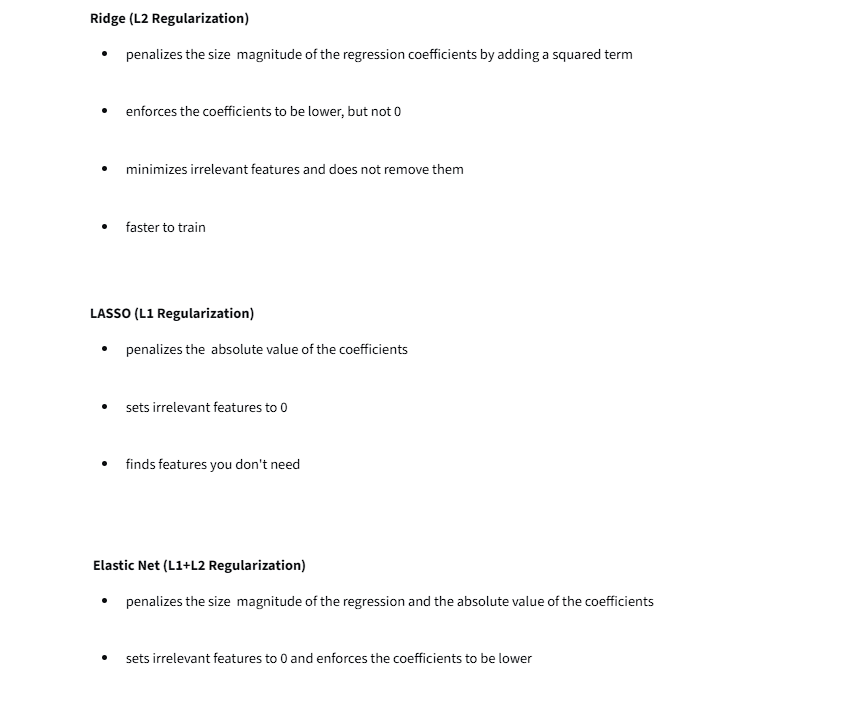


#### How to use both column transformer, pipeline and do grid search cv?


## RFE


In [ ]:

#rfecv stands for Recursive Feature Elimination with Cross-Validation. 
# It is a feature selection technique that recursively eliminates features from the dataset 
# and evaluates the performance of the model using cross-validation at each step. 
# The goal of RFECV is to identify the optimal number of features that contribute the 
# most to the predictive power of the model while avoiding overfitting.
# By using cross-validation, RFECV can provide a more robust estimate of the model's performance 
# and help in selecting the most relevant features for training the model.

from sklearn.feature_selection import RFECV 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


model = LogisticRegression(random_state=42, max_iter=1000)
rfecv = RFECV(estimator=model, step=1, cv=5, scoring='accuracy') #scoring parameter is used to specify the metric that will be used to evaluate the performance of the model during the cross-validation process. In this case, 'accuracy' is chosen as the scoring metric, which means that the model's performance will be evaluated based on its accuracy in correctly classifying the samples. The RFECV will use this scoring metric to determine which features to select and which to eliminate during the recursive feature elimination process.

# Step 2: Fit RFECV on training data
rfecv.fit(X_train, y_train)

# Step 3: Get results
print(f"Optimal number of features: {rfecv.n_features_to_select_}")
print(f"Selected features: {rfecv.support_}")
print(f"Feature ranking: {rfecv.ranking_}")

# Step 4: Transform data
X_train_selected = rfecv.transform(X_train)
X_test_selected = rfecv.transform(X_test)

# Step 5: Train final model on selected features
model.fit(X_train_selected, y_train)

# Step 6: Make predictions
y_pred = model.predict(X_test_selected)
y_pred_proba = model.predict_proba(X_test_selected)

# Step 7: Evaluate
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

### Classification metrics


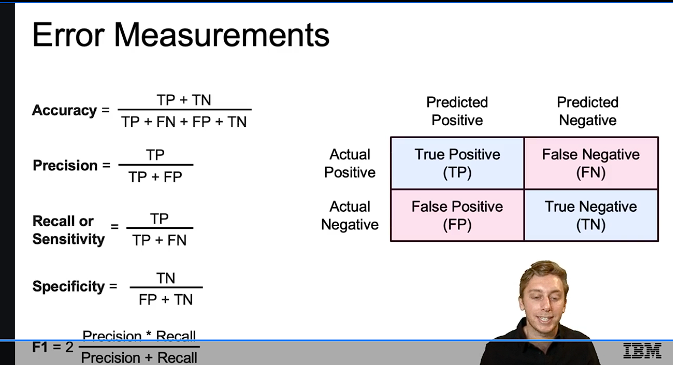


In [ ]:

from sklearn.metrics import accuracy_score,recall_score,f1_score,confusion_matrix,precision_score,classification_report# classification_report command is used to generate a text report showing the main classification metrics such as precision, recall, f1-score, and support for each class. It takes the true labels (y_test) and the predicted labels (y_pred) as input and provides a summary of the performance of the classification model. The report includes metrics for each class, as well as overall metrics such as accuracy, macro average, and weighted average. This report is useful for evaluating the performance of a classification model and understanding how well it is performing on different classes.


print(accuracy_score(y_test,y_pred)) 

print(precision_score(y_test,y_pred)) # average='weighted','macro','none' 

print(recall_score(y_test,y_pred))

print(f1_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

print(classification_report(y_test,y_pred))

In [ ]:
clf = LogisticRegression(multi_class='multinomial')

In [ ]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values, y.values, clf, legend=2)

In [ ]:
#for non linear data classification

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3,include_bias=False)

#how to decide degree of polynomial features is a common question in machine learning. 
# The degree of polynomial features can be determined through a process called model selection,
# which involves evaluating the performance of the model with different degrees of polynomial features 
# and selecting the one that provides the best performance on a validation set or 
# through cross-validation.

X_trf = poly.fit_transform(X)

clf1 = LogisticRegression()

np.mean(cross_val_score(clf1,X_trf,y,scoring='accuracy',cv=10))

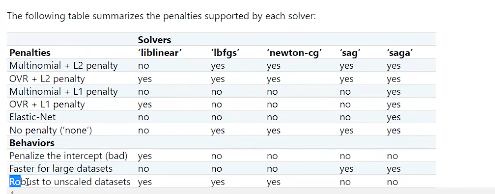

In [ ]:
sgdcla = SGDRegressor(alpha=0.005,penalty='l2')
sgdcla.fit(X_train,y_train)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42, max_depth=5,splitter='best',max_features=None)  
#random_state is used to ensure reproducibility of results, 
# while max_depth limits the depth of the tree to prevent overfitting.
# The splitter parameter determines the strategy used to choose the split at each node. 
# 'best' means that the algorithm will choose the best split based on the chosen criterion 
# (e.g., Gini impurity or entropy) to maximize the separation of the classes at each node.
# max_features parameter specifies the number of features to consider when looking for the best split.
#none max_features means that all features will be considered 
# Fit the model on training data
dt.fit(X_train, y_train)

# Make predictions
y_pred = dt.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

In [ ]:
from sklearn.model_selection import GridSearchCV

# After fitting the DecisionTreeClassifier (dt), you can get the maximum depth of the trained tree using:
max_depth = dt.get_depth()
# After fitting the DecisionTreeClassifier (dt), you can get the maximum depth of the trained tree using:
max_depth = dt.get_depth()
print(f"Maximum depth of the decision tree: {max_depth}")

# To decide the best depth for a decision tree, use GridSearchCV to tune the max_depth hyperparameter

param_grid = {'max_depth': [3, 5, 7, 10, None]}  # Example depths; adjust as needed
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
#scoring parameter is used to specify the metric that will be used to evaluate the performance 
# of the model during the cross-validation process. 
# In this case, 'accuracy' is chosen as the scoring metric, 
# which means that the model's performance will be evaluated based on its accuracy 
# in correctly classifying the samples. 
# The GridSearchCV will use this scoring metric to determine which max_depth value provides the 
# best performance during the cross-validation process.

grid_search.fit(X_train, y_train)
best_depth = grid_search.best_params_['max_depth']
print(f"Best max_depth found: {best_depth}")


# Retrain with best depth
dt_best = DecisionTreeClassifier(random_state=42, max_depth=best_depth)
dt_best.fit(X_train, y_train)
y_pred_best = dt_best.predict(X_test)
print(f"Accuracy with best depth: {accuracy_score(y_test, y_pred_best):.4f}")

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_reg= DecisionTreeRegressor(random_state=42, max_depth=5,splitter='best',max_features=None,criterion='squared_error')
dt_reg.fit(X_train, y_train)
y_pred_reg = dt_reg.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_reg):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_reg):.4f}")
print(f"Root Mean Squared Error: {mean_squared_error(y_test, y_pred_reg, squared=False):.4f}")
print(f"R-squared: {r2_score(y_test, y_pred_reg):.4f}")